<a href="https://colab.research.google.com/github/arjanafridi123/Nassau-Candy-Distributor-Analysis/blob/main/Nassau_Candy_Distributor_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Product Line Profitability & Margin Performance Analysis for Nassau Candy Distributor**

# **Business Problem Statement**

Nassau Candy distributes a large portfolio of products across multiple divisions and categories. While high sales volume is often considered a sign of success, it does not always translate into strong profitability. Some products generate significant revenue but contribute little profit due to high costs, while others deliver excellent margins despite lower sales volumes.

The objective of this analysis is to identify the products, categories, and divisions that drive profitability, evaluate cost efficiency, detect pricing and margin issues, and uncover revenue concentration risks. The findings will support better inventory planning, pricing strategies, supplier negotiations, and product portfolio optimization.

# **Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Dataset Overview**

In [3]:
df = pd.read_csv('/content/Nassau Candy Distributor.csv')

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [5]:
df.shape

(10194, 18)

# **Data Cleaning & Validation**

In [6]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Country/Region,0
City,0
State/Province,0
Postal Code,0


In [7]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [9]:
# Create a copy of the original dataset to preserve raw data
nassau_df = df.copy()

In [10]:
# Convert Order Date column to datetime format for chronological sales analysis
nassau_df['Order Date'] = pd.to_datetime(nassau_df['Order Date'], dayfirst=True)

# Convert Ship Date column to datetime format for shipping and delivery analysis
nassau_df['Ship Date'] = pd.to_datetime(nassau_df['Ship Date'], dayfirst=True)

In [11]:
# Check updated data types after converting date columns to datetime format
nassau_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  int64         
 6   Country/Region  10194 non-null  object        
 7   City            10194 non-null  object        
 8   State/Province  10194 non-null  object        
 9   Postal Code     10194 non-null  object        
 10  Division        10194 non-null  object        
 11  Region          10194 non-null  object        
 12  Product ID      10194 non-null  object        
 13  Product Name    10194 non-null  object        
 14  Sales           10194 non-null  float64       
 15  Un

# **Invalid Value Detection**

In [12]:
# Check for records with zero or negative sales values
nassau_df[nassau_df['Sales'] <= 0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost


In [13]:
# Check for records with zero or negative cost values
nassau_df[nassau_df['Cost'] <= 0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost


In [14]:
# Check for records with zero or negative unit quantities
nassau_df[nassau_df['Units'] <= 0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost


In [15]:
# Check for records with zero or negative gross profit values
nassau_df[nassau_df['Gross Profit'] <= 0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost


- Verified the dataset for zero or negative values in key business metrics including Sales, Cost, Units, and Gross Profit.
- No invalid records were identified, indicating that the dataset is suitable for profitability and margin analysis.
- The absence of invalid values reduces the risk of distorted business insights and improves analytical reliability.

In [16]:
# Generate summary statistics for numerical columns to understand data distribution
nassau_df.describe()

,Row ID,Order Date,Ship Date,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-03-13 03:08:26.415538176,2028-10-23 23:20:43.790465024,134468.961154,13.908537,3.791838,9.166451,4.742087
min,1.000000,2024-01-02 00:00:00,2026-06-30 00:00:00,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,2024-09-28 00:00:00,2027-11-09 00:00:00,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,2025-04-06 12:00:00,2028-12-18 00:00:00,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,2025-09-16 00:00:00,2029-11-08 00:00:00,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,2025-12-31 00:00:00,2030-06-28 00:00:00,192314.000000,260.000000,14.000000,130.000000,130.000000
std,2942.898656,NaN,NaN,20231.483007,11.341020,2.228317,6.643740,5.061647


# **Duplicate Record Check**

In [17]:
# Identify duplicate records in the dataset
nassau_df[nassau_df.duplicated()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost


- No duplicate records were found in the dataset.
- Each transaction appears to be unique, ensuring data integrity for profitability analysis.

# **Data Standardization**

In [18]:
# Rename Country/Region column for consistency and easier reference
nassau_df.rename(columns={'Country/Region':'Country'}, inplace=True)

In [19]:
# Review summary statistics for categorical columns
nassau_df.describe(include='object')

,Order ID,Ship Mode,Country,City,State/Province,Postal Code,Division,Region,Product ID,Product Name
count,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194
unique,8549,4,2,542,59,654,3,4,15,15
top,US-2022-130974-CHO-SCR-58000,Standard Class,United States,New York City,California,10035,Chocolate,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate
freq,5,6120,9994,915,2001,263,9844,3253,2137,2137


# **Categorical Data Validation**

In [20]:
# Count unique values in key categorical variables
categorical_cols = ['Country', 'City', 'State/Province', 'Division', 'Region', 'Product Name']

for col in categorical_cols:
    print(f"{col}: {nassau_df[col].nunique()}")

Country: 2
City: 542
State/Province: 59
Division: 3
Region: 4
Product Name: 15


# **Product Category Verification**

In [21]:
# Display all unique product categories available in the dataset
nassau_df['Product Name'].unique()

array(['Wonka Bar - Milk Chocolate', 'Wonka Bar - Triple Dazzle Caramel',
       'Wonka Bar - Nutty Crunch Surprise',
       'Wonka Bar -Scrumdiddlyumptious', 'Wonka Bar - Fudge Mallows',
       'Wonka Gum', 'Kazookles', 'Lickable Wallpaper',
       'Fizzy Lifting Drinks', 'Laffy Taffy', 'SweeTARTS', 'Nerds',
       'Hair Toffee', 'Everlasting Gobstopper', 'Fun Dip'], dtype=object)

# **Division Category Verification**

In [22]:
# Display all business divisions represented in the dataset
nassau_df['Division'].unique()

array(['Chocolate', 'Other', 'Sugar'], dtype=object)

# **Feature Engineering**

In [23]:
# Calculate Gross Margin Percentage to measure profitability relative to sales
nassau_df['Gross_Margin_%'] = ((nassau_df['Gross Profit'] / nassau_df['Sales']) * 100).round(2)

# Calculate Profit Per Unit to evaluate profit earned from each unit sold
nassau_df['Profit Per Unit'] = nassau_df['Gross Profit'] / nassau_df['Units']

# Extract Month from Order Date for monthly profitability trend analysis
nassau_df['Month'] = nassau_df['Order Date'].dt.month_name()

# Extract Year from Order Date for yearly performance analysis
nassau_df['Year'] = nassau_df['Order Date'].dt.year

In [24]:
# Verify created features and inspect sample records
nassau_df[['Sales', 'Units', 'Gross Profit', 'Cost', 'Gross_Margin_%', 'Profit Per Unit', 'Month', 'Year']].head()

,Sales,Units,Gross Profit,Cost,Gross_Margin_%,Profit Per Unit,Month,Year
0,6.50,2,4.22,2.28,64.92,2.11,January,2024
1,7.50,2,4.90,2.60,65.33,2.45,January,2024
2,10.47,3,7.47,3.00,71.35,2.49,January,2024
3,10.80,3,7.50,3.30,69.44,2.50,January,2024
4,11.25,3,7.35,3.90,65.33,2.45,January,2024


- Gross Margin % was created to measure how efficiently revenue is converted into profit.
- Profit Per Unit helps identify products generating the highest profit on a per-unit basis.
- Month and Year features enable time-series analysis of sales and profitability trends.
- Verification confirms that all engineered features were created successfully and are ready for further analysis.

# **Product-Level Profitability Analysis**

# **Top Products by Gross Profit**

In [25]:
# Calculate total gross profit generated by each product
product_profit = nassau_df.groupby('Product Name')['Gross Profit'].sum().sort_values(ascending=False)

top_10_profit_df = product_profit.head(10).reset_index()
top_10_profit_df.columns=['Product Name', 'Gross Profit']

In [26]:
top_10_profit_df

,Product Name,Gross Profit
0,Wonka Bar -Scrumdiddlyumptious,19357.50
1,Wonka Bar - Triple Dazzle Caramel,18610.20
2,Wonka Bar - Milk Chocolate,17443.37
3,Wonka Bar - Nutty Crunch Surprise,16819.95
4,Wonka Bar - Fudge Mallows,16593.60
5,Lickable Wallpaper,3930.00
6,Wonka Gum,310.70
7,Everlasting Gobstopper,104.00
8,Kazookles,92.75
9,Hair Toffee,59.50


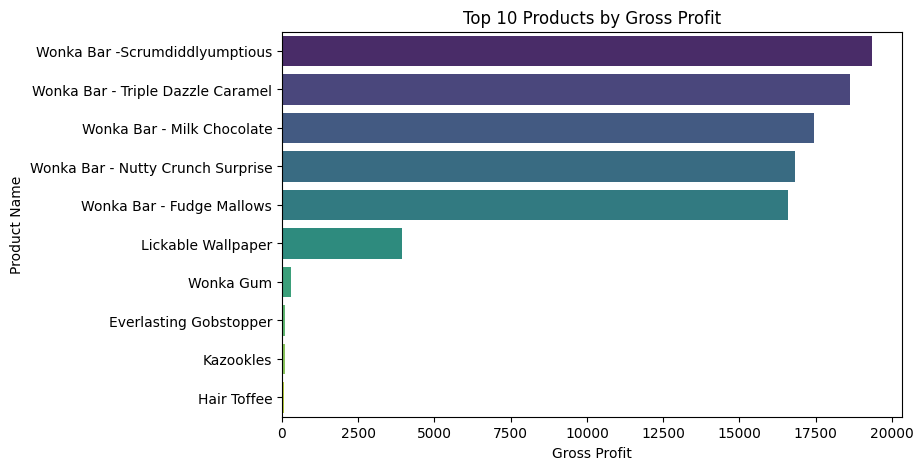

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(data=top_10_profit_df, x='Gross Profit', y='Product Name', hue='Product Name', palette='viridis', legend=False)

plt.title('Top 10 Products by Gross Profit')
plt.xlabel('Gross Profit')
plt.ylabel('Product Name')
plt.show()

- Wonka Bar - Scrumdiddlyumptious is the highest profit-generating product, contributing approximately 19.36K in gross profit.
- Wonka Bar - Triple Dazzle Caramel, Milk Chocolate, Nutty Crunch Surprise, and Fudge Mallows are also major profit drivers.
- The top five products contribute significantly more profit than the remaining products.
- There is a sharp drop in profitability after the fifth-ranked product, indicating strong profit concentration among a small number of products.
- Products such as Hair Toffee, Kazookles, and Everlasting Gobstopper contribute relatively little profit compared to the leading products.

# **Top Products by Gross Margin (%)**

In [28]:
product_margin = nassau_df.groupby('Product Name')['Gross_Margin_%'].mean().sort_values(ascending=False)
product_margin

,Gross_Margin_%
Product Name,
Everlasting Gobstopper,80.00
Hair Toffee,77.78
Wonka Bar - Nutty Crunch Surprise,71.35
Wonka Bar -Scrumdiddlyumptious,69.44
Wonka Bar - Fudge Mallows,66.67
Wonka Bar - Triple Dazzle Caramel,65.33
Wonka Bar - Milk Chocolate,64.92
Laffy Taffy,62.31
Fizzy Lifting Drinks,60.00


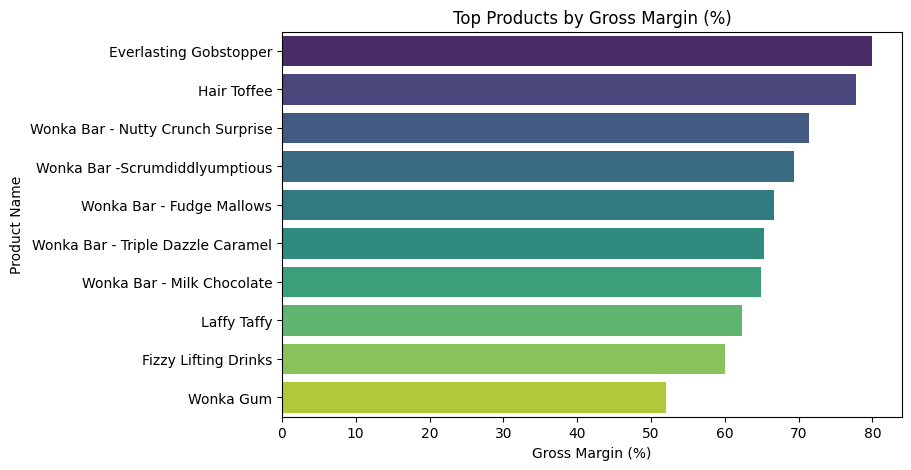

In [29]:
top_margin = product_margin.head(10).reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=top_margin,
    x='Gross_Margin_%',
    y='Product Name',
    hue='Product Name',
    palette='viridis',
    legend=False
)

plt.title('Top Products by Gross Margin (%)')
plt.xlabel('Gross Margin (%)')
plt.ylabel('Product Name')

plt.show()

- Everlasting Gobstopper achieves the highest gross margin at approximately 80%, making it the most efficient product in converting revenue into profit.
- Hair Toffee follows closely with a margin of nearly 78%.
- Several Wonka Bar products, including Nutty Crunch Surprise, Scrumdiddlyumptious, and Fudge Mallows, maintain margins above 65%, demonstrating strong profitability.
- High-margin products are not necessarily the highest-profit products, highlighting the difference between profitability efficiency and total profit contribution.
- The majority of top-margin products maintain margins above 60%, indicating a generally healthy pricing structure.

# **Top Products by Gross Margin (%)**

In [30]:
product_summary = nassau_df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Gross Profit': 'sum',
    'Gross_Margin_%': 'mean'
    }).sort_values(by='Gross_Margin_%', ascending=False)

product_summary

,Sales,Gross Profit,Gross_Margin_%
Product Name,,,
Everlasting Gobstopper,130.00,104.00,80.00
Hair Toffee,76.50,59.50,77.78
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.35
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.44
Wonka Bar - Fudge Mallows,24890.40,16593.60,66.67
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.33
Wonka Bar - Milk Chocolate,26867.75,17443.37,64.92
Laffy Taffy,53.73,33.48,62.31
Fizzy Lifting Drinks,78.75,47.25,60.00


I created a product-level summary table by aggregating total sales, total gross profit, and average gross margin for each product. This table served as the foundation for ranking products and identifying high-performing and underperforming product categories.

# **High-Profit & High-Margin Products**

In [31]:
avg_profit = product_summary['Gross Profit'].mean()
avg_margin = product_summary['Gross_Margin_%'].mean()

high_profit_high_margin = product_summary[
    (product_summary['Gross Profit'] > avg_profit) &
    (product_summary['Gross_Margin_%'] > avg_margin)
].sort_values(by='Gross Profit', ascending=False)

high_profit_high_margin

,Sales,Gross Profit,Gross_Margin_%
Product Name,,,
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.44
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.33
Wonka Bar - Milk Chocolate,26867.75,17443.37,64.92
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.35
Wonka Bar - Fudge Mallows,24890.40,16593.60,66.67


- Five Wonka Bar products qualify as both high-profit and high-margin products.
- Wonka Bar – Scrumdiddlyumptious generates the highest gross profit while maintaining a gross margin above the portfolio average.
- These products represent Nassau Candy's most valuable product segment, contributing strongly to both revenue and profitability.
- Focusing inventory availability and promotional efforts on these products can maximize profit growth.

# **High-Sales & Low-Margin Products**

In [32]:
avg_sales = product_summary['Sales'].mean()
avg_margin = product_summary['Gross_Margin_%'].mean()

high_sales_low_margin = product_summary[
    (product_summary['Sales'] > avg_sales) &
    (product_summary['Gross_Margin_%'] < avg_margin)]

high_sales_low_margin

,Sales,Gross Profit,Gross_Margin_%
Product Name,,,


No products fall into this category, indicating that high-selling products maintain above-average profitability. This reflects a strong balance between sales performance and profit generation.

In [33]:
print("Average Sales:", avg_sales)
print("Average Margin:", avg_margin)

Average Sales: 9452.242
Average Margin: 57.38866666666666


Average product sales are 9,452.24 and average gross margin is 57.39%. These values serve as reference points for identifying high-performing and underperforming products.

# **Low-Sales & Low-Profit Products**

In [34]:
avg_profit = product_summary['Gross Profit'].mean()

low_sales_low_profit = product_summary[
    (product_summary['Sales'] < avg_sales) &
    (product_summary['Gross Profit'] < avg_profit)]

low_sales_low_profit

,Sales,Gross Profit,Gross_Margin_%
Product Name,,,
Everlasting Gobstopper,130.00,104.00,80.00
Hair Toffee,76.50,59.50,77.78
Laffy Taffy,53.73,33.48,62.31
Fizzy Lifting Drinks,78.75,47.25,60.00
Wonka Gum,597.50,310.70,52.00
Lickable Wallpaper,7860.00,3930.00,50.00
Nerds,15.00,7.00,46.67
SweeTARTS,61.50,28.70,46.67
Fun Dip,12.00,4.80,40.00


- Products such as Hair Toffee, Laffy Taffy, Nerds, Fun Dip, and Fizzy Lifting Drinks generate below-average sales and below-average profit.
- These products contribute minimally to overall business performance and profitability.
- Management should review pricing, promotional strategies, and inventory allocation for these products.
- If performance does not improve, these products may be candidates for reduced stocking or portfolio optimization.

# **Division-Level Performance Analysis**

# **Division Performance Summary**

In [35]:
division_summary = nassau_df.groupby('Division').agg({
    'Sales':'sum',
    'Gross Profit':'sum',
    'Gross_Margin_%':'mean'
}).sort_values(by='Sales', ascending=False)

division_summary

,Sales,Gross Profit,Gross_Margin_%
Division,,,
Chocolate,131692.90,88824.62,67.457102
Other,9663.25,4333.45,37.671742
Sugar,427.48,284.73,57.690000


# **Revenue Performance by Division**

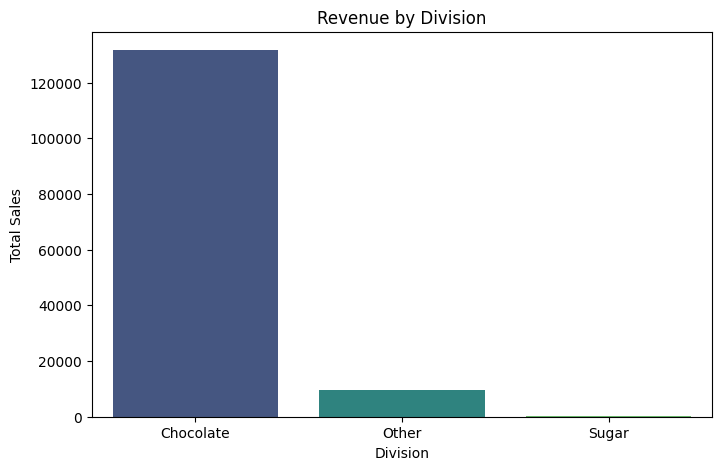

In [36]:
plt.figure(figsize=(8,5))

sns.barplot( data=division_summary.reset_index(), x='Division', y='Sales', hue='Division', palette='viridis', legend=False)

plt.title('Revenue by Division')
plt.xlabel('Division')
plt.ylabel('Total Sales')

plt.show()

- The Chocolate division dominates revenue generation, contributing the vast majority of total sales.
- The Other division contributes significantly less revenue than Chocolate.
- The Sugar division has minimal sales contribution and represents the smallest revenue-generating division.

# **Average Gross Margin by Division**

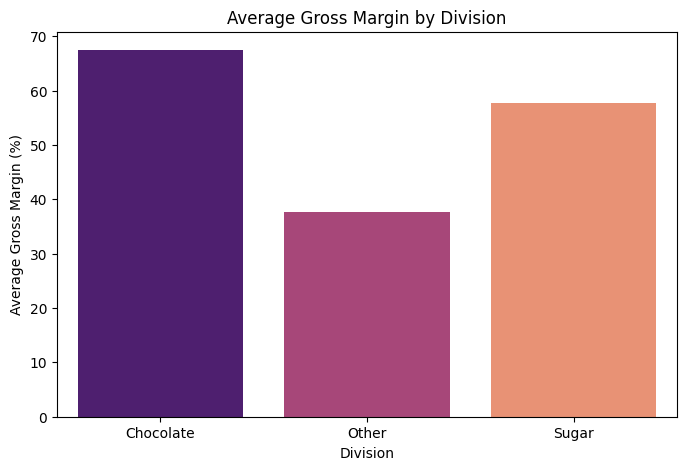

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(data=division_summary.reset_index(), x='Division', y='Gross_Margin_%', hue='Division', palette='magma', legend=False)

plt.title('Average Gross Margin by Division')
plt.xlabel('Division')
plt.ylabel('Average Gross Margin (%)')

plt.show()

- The Chocolate division has the highest average gross margin (~67%), making it the most profitable division.
- The Sugar division maintains a healthy margin (~58%), despite generating relatively low sales.
- The Other division has the lowest margin (~38%), indicating weaker profitability compared to the other divisions.

# **Profit Conversion Efficiency by Division**

In [38]:
division_summary['Profit_Conversion_%'] = (division_summary['Gross Profit'] / division_summary['Sales']) * 100

division_summary[['Profit_Conversion_%']]

,Profit_Conversion_%
Division,
Chocolate,67.448298
Other,44.844643
Sugar,66.606625


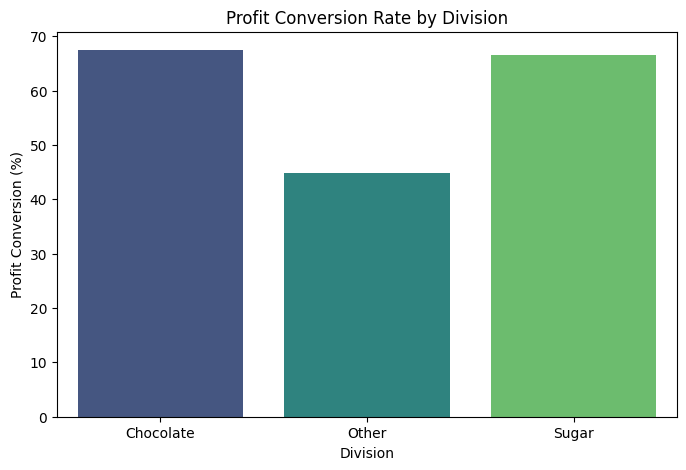

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(data=division_summary.reset_index(), x='Division', y='Profit_Conversion_%', hue='Division', palette='viridis', legend=False)

plt.title('Profit Conversion Rate by Division')
plt.ylabel('Profit Conversion (%)')
plt.show()

- The Chocolate division has the highest profit conversion rate (~67%), meaning it converts the largest share of revenue into profit.
- The Sugar division performs nearly as well (~66%), showing strong profitability despite lower sales volume.
- The Other division has the lowest conversion rate (~45%), indicating lower efficiency in generating profit from sales.

In [40]:
avg_sales = division_summary['Sales'].mean()
avg_profit = division_summary['Gross Profit'].mean()
avg_margin = division_summary['Gross_Margin_%'].mean()

strong_efficiency = division_summary[
    (division_summary['Sales'] > avg_sales) &
    (division_summary['Gross Profit'] > avg_profit) &
    (division_summary['Gross_Margin_%'] > avg_margin)]

strong_efficiency

,Sales,Gross Profit,Gross_Margin_%,Profit_Conversion_%
Division,,,,
Chocolate,131692.9,88824.62,67.457102,67.448298


The Chocolate division is the only division exceeding the company average in sales, profit, and margin, making it the strongest and most financially efficient division.

# **Strong Financial Efficiency Divisions**

In [41]:
margin_issue = division_summary[
    (division_summary['Sales'] > avg_sales) &
    (division_summary['Gross_Margin_%'] < avg_margin)]

margin_issue

,Sales,Gross Profit,Gross_Margin_%,Profit_Conversion_%
Division,,,,


No division was found with high sales but below-average margins. This indicates that revenue growth is not currently being achieved at the expense of profitability.

# **Profit Concentration (Pareto) Analysis**

# **Determine % of Products Contributing 80% of Revenue**

In [42]:
revenue_pareto = product_summary.sort_values(by='Sales', ascending=False)

revenue_pareto['Revenue_%'] = round((revenue_pareto['Sales'] / revenue_pareto['Sales'].sum()) * 100, 2)

revenue_pareto['Cumulative_Revenue_%'] = round(revenue_pareto['Revenue_%'].cumsum(), 2)

revenue_80 = revenue_pareto[revenue_pareto['Cumulative_Revenue_%'] <= 80]

In [43]:
revenue_80

,Sales,Gross Profit,Gross_Margin_%,Revenue_%,Cumulative_Revenue_%
Product Name,,,,,
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.33,20.09,20.09
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.44,19.66,39.75
Wonka Bar - Milk Chocolate,26867.75,17443.37,64.92,18.95,58.70
Wonka Bar - Fudge Mallows,24890.40,16593.60,66.67,17.56,76.26


In [44]:
product_percent_revenue = (len(revenue_80) / len(product_summary)) * 100

print(f"{product_percent_revenue:.2f}% of products generate 80% of revenue")

26.67% of products generate 80% of revenue


# **Revenue Pareto Chart**

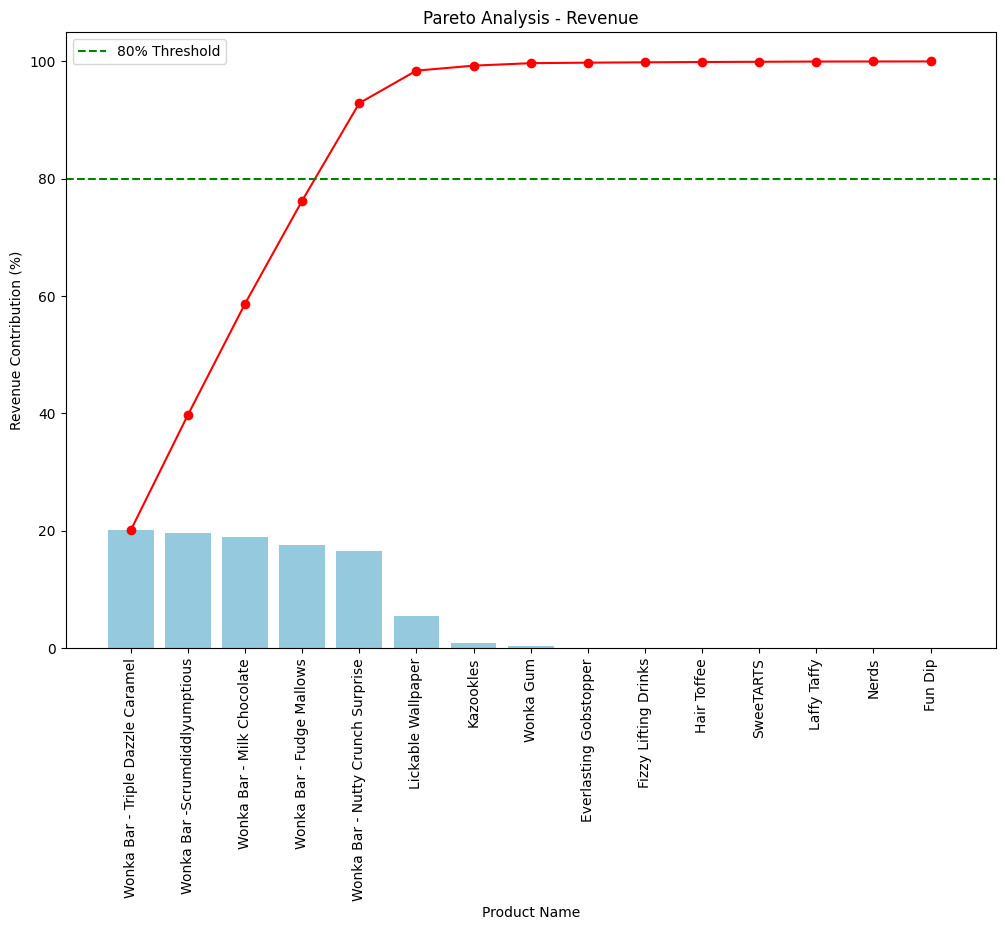

In [45]:
plt.figure(figsize=(12,8))

sns.barplot(x=revenue_pareto.index, y=revenue_pareto['Revenue_%'], color='skyblue')

plt.plot(revenue_pareto.index, revenue_pareto['Cumulative_Revenue_%'], color='red',marker='o')
plt.axhline(y=80, color='green', linestyle='--', label='80% Threshold')

plt.title('Pareto Analysis - Revenue')
plt.ylabel('Revenue Contribution (%)')
plt.legend()
plt.xticks(rotation=90)

plt.show()

- The first few products contribute a disproportionately large share of total revenue, as shown by the steep rise in the cumulative revenue curve.
- The cumulative contribution crosses the 80% threshold after only a small number of top-performing products.
- Revenue contribution drops sharply beyond the leading products, indicating a long tail of low-revenue products.
- Wonka Bar product variants dominate revenue generation, with the highest bars appearing at the beginning of the chart.
- The business exhibits a strong Pareto pattern, where a small subset of products drives most of the revenue.

# **Determine % of Products Contributing 80% of Profit**

In [46]:
profit_pareto = product_summary.sort_values(by='Gross Profit', ascending=False)

profit_pareto['Profit_%'] = round((profit_pareto['Gross Profit'] / profit_pareto['Gross Profit'].sum()) * 100, 2)

profit_pareto['Cumulative_Profit_%'] = round(profit_pareto['Profit_%'].cumsum(), 2)

profit_80 = profit_pareto[profit_pareto['Cumulative_Profit_%'] <= 80]

In [47]:
profit_80

,Sales,Gross Profit,Gross_Margin_%,Profit_%,Cumulative_Profit_%
Product Name,,,,,
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.44,20.72,20.72
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.33,19.92,40.64
Wonka Bar - Milk Chocolate,26867.75,17443.37,64.92,18.67,59.31
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.35,18.00,77.31


In [48]:
product_percent_profit = (len(profit_80) / len(product_summary)) * 100

print(f"{product_percent_profit:.2f}% of products generate 80% of profit")

26.67% of products generate 80% of profit


# **Profit Pareto Chart**

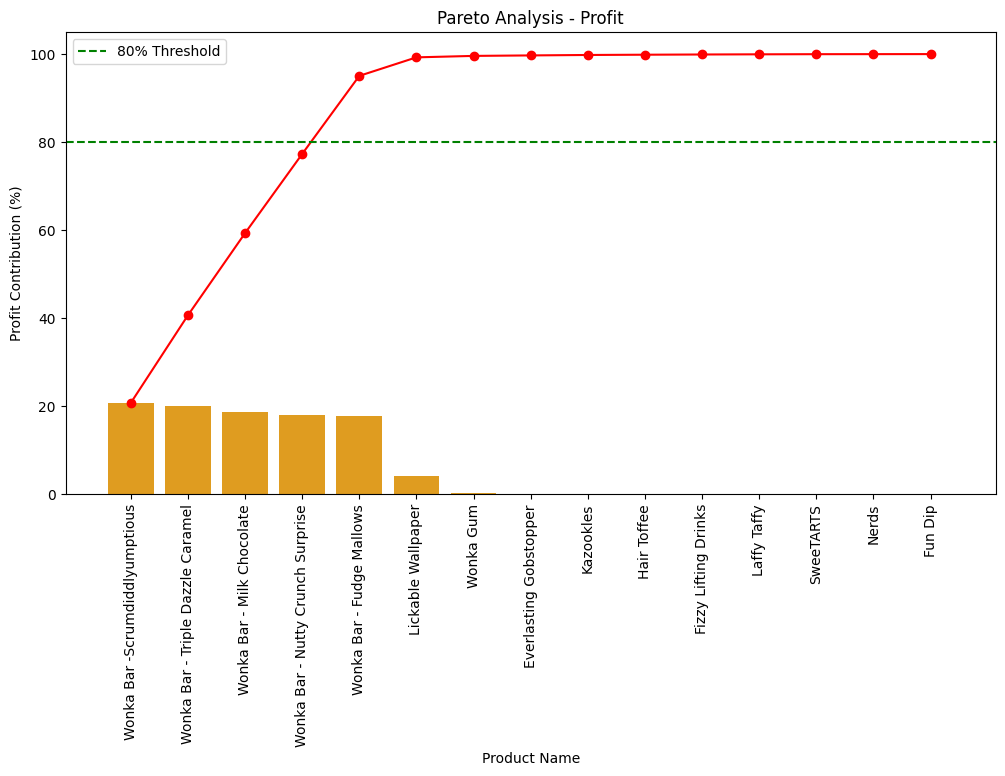

In [49]:
plt.figure(figsize=(12,6))

sns.barplot(x=profit_pareto.index, y=profit_pareto['Profit_%'], color='orange')

plt.plot(profit_pareto.index, profit_pareto['Cumulative_Profit_%'], color='red', marker='o')
plt.axhline(y=80, color='green', linestyle='--', label='80% Threshold')

plt.title('Pareto Analysis - Profit')
plt.ylabel('Profit Contribution (%)')
plt.legend()
plt.xticks(rotation=90)

plt.show()

- The cumulative profit curve rises sharply in the first few products, indicating that profit generation is heavily concentrated among top-performing products.
- The 80% profit threshold is reached after only a small subset of products, demonstrating a strong Pareto effect.
- Products such as Wonka Bar - Scrumdiddlyumptious, Triple Dazzle Caramel, Milk Chocolate, Nutty Crunch Surprise, and Fudge Mallows contribute the majority of total profit.
- After the leading products, individual profit contributions decline significantly, with most remaining products adding only marginal profit.
- Profitability is concentrated in a limited number of products, suggesting that business performance depends heavily on a few key profit drivers.

# **Detect congestion-prone states or regions & identify over-dependency risks**

In [50]:
state_summary = nassau_df.groupby('State/Province').agg({
    'Sales':'sum',
    'Gross Profit':'sum'
}).sort_values(by='Sales', ascending=False)

state_summary.head(10)

,Sales,Gross Profit
State/Province,,
California,27917.40,18479.42
New York,15541.03,10222.44
Texas,13416.09,8909.53
Pennsylvania,8027.03,5225.47
Washington,6921.15,4566.64
Illinois,6898.96,4557.68
Ohio,6768.95,4413.03
Florida,4804.02,3207.11
Arizona,3587.55,2290.11


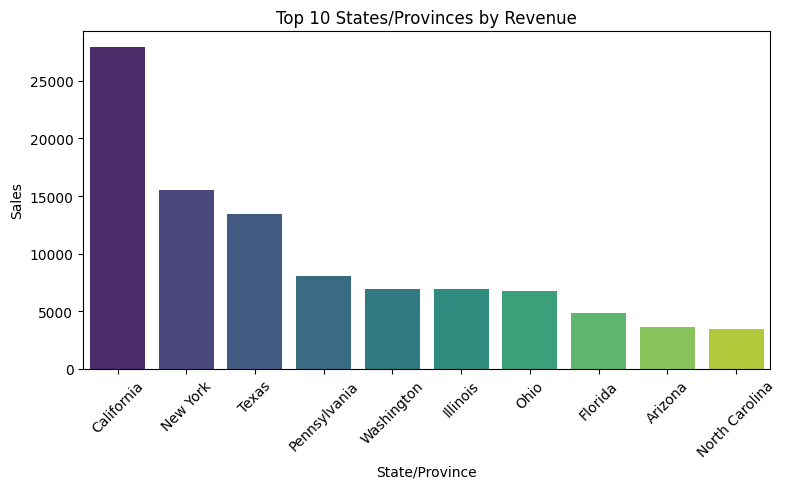

In [51]:
plt.figure(figsize=(8,5))

top_states = state_summary.head(10).reset_index()

sns.barplot(data=top_states,x='State/Province', y='Sales', hue='State/Province', palette='viridis', legend=False)

plt.title('Top 10 States/Provinces by Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- California generates the highest revenue, significantly outperforming all other states and acting as the primary revenue-driving market.
- New York and Texas rank second and third, forming a strong secondary revenue tier but still trailing California by a considerable margin.
- Revenue declines sharply after the top three states, indicating that sales are concentrated in a few key regions.
- States such as Pennsylvania, Washington, Illinois, and Ohio contribute moderate revenue levels and provide additional market support.
- The business appears to have a high dependency on California, which could create regional concentration risk if demand weakens in that market.

In [52]:
state_summary['Revenue_%'] = round((state_summary['Sales'] / state_summary['Sales'].sum()) * 100, 2)

state_summary[['Revenue_%']].head(10)

,Revenue_%
State/Province,
California,19.69
New York,10.96
Texas,9.46
Pennsylvania,5.66
Washington,4.88
Illinois,4.87
Ohio,4.77
Florida,3.39
Arizona,2.53


In [53]:
top_3_revenue = state_summary['Revenue_%'].head(3).sum()

print(f"Top 3 States contribute {top_3_revenue:.2f}% of total revenue")

Top 3 States contribute 40.11% of total revenue


In [54]:
state_pareto = state_summary.sort_values(by='Sales', ascending=False)

state_pareto['Revenue_%'] = round((state_pareto['Sales'] / state_pareto['Sales'].sum()) * 100, 2)

state_pareto['Cumulative_Revenue_%'] = round(state_pareto['Revenue_%'].cumsum(), 2)

In [55]:
state_pareto

,Sales,Gross Profit,Revenue_%,Cumulative_Revenue_%
State/Province,,,,
California,27917.40,18479.42,19.69,19.69
New York,15541.03,10222.44,10.96,30.65
Texas,13416.09,8909.53,9.46,40.11
Pennsylvania,8027.03,5225.47,5.66,45.77
Washington,6921.15,4566.64,4.88,50.65
Illinois,6898.96,4557.68,4.87,55.52
Ohio,6768.95,4413.03,4.77,60.29
Florida,4804.02,3207.11,3.39,63.68
Arizona,3587.55,2290.11,2.53,66.21


Revenue is geographically diversified. The top three states contribute only 40.11% of total revenue, indicating that sales are spread across multiple regions rather than concentrated in a few markets. This reduces geographic dependency risk compared to product-level revenue concentration.

# **Cost Structure Diagnostics**

# **Cost vs Sales Scatter Analysis**

In [56]:
product_cost_analysis = nassau_df.groupby('Product Name').agg({
    'Sales':'sum',
    'Gross Profit':'sum'
})

product_cost_analysis['Cost'] = (product_cost_analysis['Sales']- product_cost_analysis['Gross Profit'])

product_cost_analysis['Gross_Margin_%'] = round((product_cost_analysis['Gross Profit'] / product_cost_analysis['Sales']) * 100, 2)

In [57]:
product_cost_analysis.head()

,Sales,Gross Profit,Cost,Gross_Margin_%
Product Name,,,,
Everlasting Gobstopper,130.00,104.00,26.0,80.00
Fizzy Lifting Drinks,78.75,47.25,31.5,60.00
Fun Dip,12.00,4.80,7.2,40.00
Hair Toffee,76.50,59.50,17.0,77.78
Kazookles,1205.75,92.75,1113.0,7.69


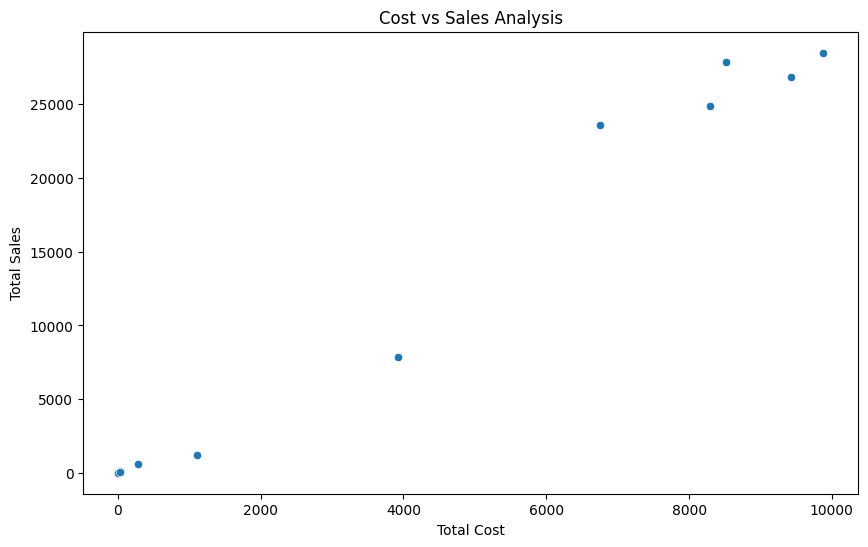

In [58]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=product_cost_analysis, x='Cost', y='Sales')

plt.title('Cost vs Sales Analysis')
plt.xlabel('Total Cost')
plt.ylabel('Total Sales')

plt.show()

- A strong positive relationship exists between product cost and sales, indicating that higher-cost products generally generate higher revenue.
- The top-performing Wonka Bar products appear in the upper-right region of the chart, showing both high costs and high sales volumes.
- Low-cost products contribute relatively little to total sales and remain clustered near the origin.
- No major outliers are visible, suggesting a consistent cost-to-sales pattern across the product portfolio.

# **Cost-Heavy, Margin-Poor Products**

In [59]:
cost_heavy_products = product_cost_analysis[product_cost_analysis['Gross_Margin_%'] < 30]

cost_heavy_products.sort_values(by='Gross_Margin_%')

,Sales,Gross Profit,Cost,Gross_Margin_%
Product Name,,,,
Kazookles,1205.75,92.75,1113.0,7.69


Kazookles is the only product with a gross margin below 30%, indicating that high costs are significantly reducing its profitability.

# **Products Needing Cost Renegotiation**

In [60]:
cost_renegotiation = product_cost_analysis[product_cost_analysis['Cost'] > product_cost_analysis['Cost'].median()].sort_values(by='Cost', ascending=False)
cost_renegotiation

,Sales,Gross Profit,Cost,Gross_Margin_%
Product Name,,,,
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,9874.80,65.33
Wonka Bar - Milk Chocolate,26867.75,17443.37,9424.38,64.92
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,8517.30,69.44
Wonka Bar - Fudge Mallows,24890.40,16593.60,8296.80,66.67
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,6755.00,71.35
Lickable Wallpaper,7860.00,3930.00,3930.00,50.00
Kazookles,1205.75,92.75,1113.00,7.69


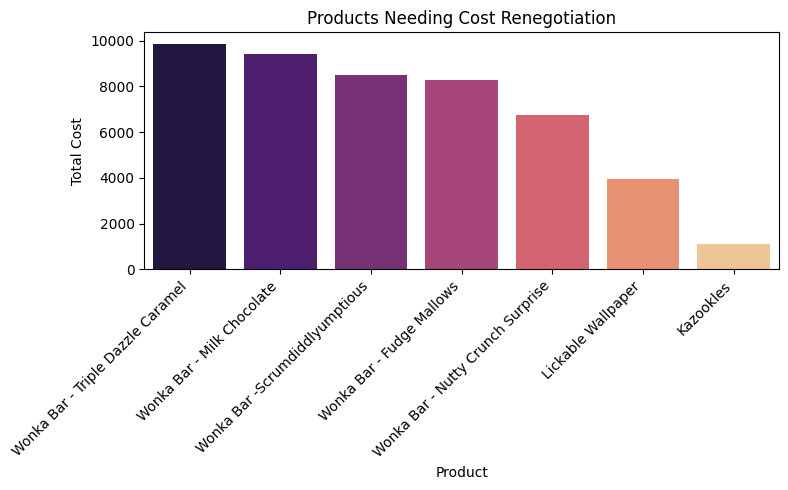

In [61]:
plt.figure(figsize=(8,5))

sns.barplot(x=cost_renegotiation.index, y=cost_renegotiation['Cost'], hue=cost_renegotiation.index, palette='magma', legend=False)

plt.title('Products Needing Cost Renegotiation')
plt.xlabel('Product')
plt.ylabel('Total Cost')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

- Wonka Bar – Triple Dazzle Caramel has the highest total cost, making it the top candidate for supplier cost optimization.
- Multiple Wonka Bar variants dominate the high-cost category, indicating cost concentration within a single product family.
- Despite strong profitability, these products consume substantial resources, creating opportunities for margin improvement through cost reductions.
- Kazookles has the lowest absolute cost among the selected products but remains a concern due to its extremely low margin.
- Reducing costs for high-volume Wonka products could generate a larger profit impact than focusing on lower-volume items.

# **Products for Discontinuation Review**

In [62]:
discontinue_review = product_cost_analysis[
    (product_cost_analysis['Sales'] < product_cost_analysis['Sales'].median()) &
    (product_cost_analysis['Gross Profit'] < product_cost_analysis['Gross Profit'].median())].sort_values(by='Sales', ascending=False)

discontinue_review

,Sales,Gross Profit,Cost,Gross_Margin_%
Product Name,,,,
Fizzy Lifting Drinks,78.75,47.25,31.50,60.00
Hair Toffee,76.50,59.50,17.00,77.78
SweeTARTS,61.50,28.70,32.80,46.67
Laffy Taffy,53.73,33.48,20.25,62.31
Nerds,15.00,7.00,8.00,46.67
Fun Dip,12.00,4.80,7.20,40.00


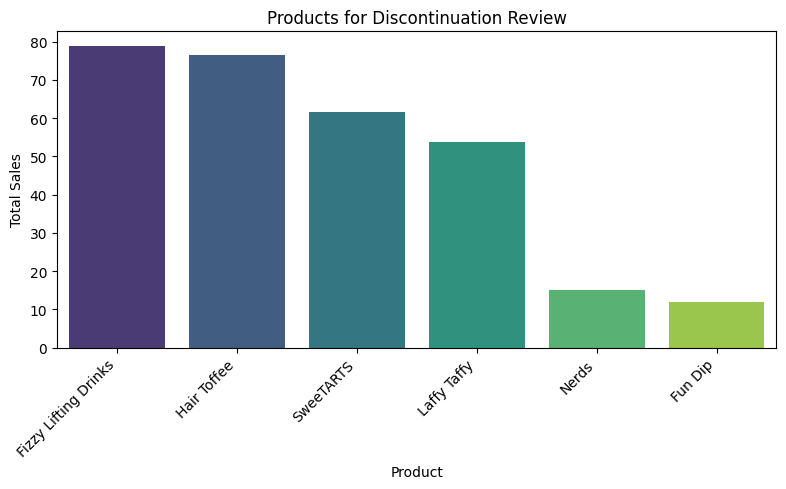

In [63]:
plt.figure(figsize=(8,5))

sns.barplot(x=discontinue_review.index, y=discontinue_review['Sales'], hue=discontinue_review.index, palette='viridis', legend=False)

plt.title('Products for Discontinuation Review')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

- Fizzy Lifting Drinks and Hair Toffee generate the highest sales among products flagged for review, but their overall contribution remains relatively small.
- Nerds and Fun Dip have the lowest sales, indicating weak market demand compared to other products.
- All listed products fall below both median sales and median gross profit, making them underperformers within the portfolio.
- The large sales gap between the top and bottom products suggests inconsistent product performance across the category.
- These products may be consuming inventory, shelf space, and operational resources without generating meaningful business impact.

# **Time-Based Revenue Analysis**

# **Monthly Revenue Trend**

In [64]:
monthly_revenue = (nassau_df.groupby(['Year', 'Month'])['Sales'].sum().reset_index())

month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']

monthly_revenue['Month'] = pd.Categorical(monthly_revenue['Month'], categories=month_order, ordered=True)
monthly_revenue = monthly_revenue.sort_values(['Year', 'Month'])

In [65]:
monthly_revenue

,Year,Month,Sales
4,2024,January,2093.90
3,2024,February,1379.87
7,2024,March,4138.90
0,2024,April,3988.22
8,2024,May,3951.52
6,2024,June,3518.76
5,2024,July,3865.38
1,2024,August,4477.65
11,2024,September,7912.10
10,2024,October,4815.98


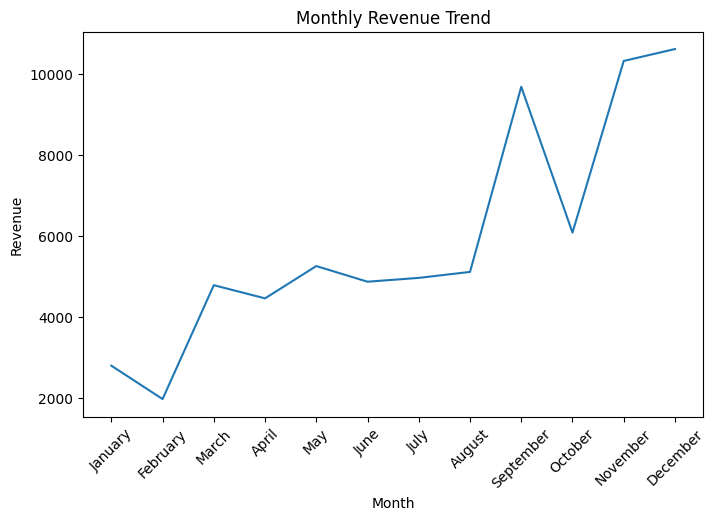

In [66]:
plt.figure(figsize=(8,5))

sns.lineplot(data=monthly_revenue, x='Month', y='Sales', errorbar=None)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.show()

- Revenue remained relatively low and stable during the first half of the year, with a noticeable dip in February.
- Revenue gradually increased from March to August, indicating steady growth in sales performance.
- A significant revenue spike occurred in September, suggesting strong seasonal demand or promotional activity.
- Revenue declined in October after the September peak but recovered sharply in November.
- November and December recorded the highest revenue levels, making them the strongest-performing months of the year.
- The overall trend indicates that sales are heavily concentrated in the second half of the year, particularly during the holiday season.

# **Monthly Average Margin**

In [67]:
monthly_margin = (nassau_df.groupby(['Year', 'Month'])['Gross_Margin_%'].mean().reset_index()).round(2)

month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']

monthly_margin['Month'] = pd.Categorical(monthly_margin['Month'], categories=month_order, ordered=True)
monthly_margin = monthly_margin.sort_values(['Year', 'Month'])

In [68]:
monthly_margin

,Year,Month,Gross_Margin_%
4,2024,January,65.92
3,2024,February,66.26
7,2024,March,65.60
0,2024,April,66.74
8,2024,May,66.34
6,2024,June,66.32
5,2024,July,66.29
1,2024,August,66.40
11,2024,September,66.78
10,2024,October,66.27


# **Calculate Margin Volatility**

In [69]:
margin_volatility = monthly_margin['Gross_Margin_%'].std()
print(f"Margin Volatility (Std Dev): {margin_volatility:.2f}%")

Margin Volatility (Std Dev): 0.32%


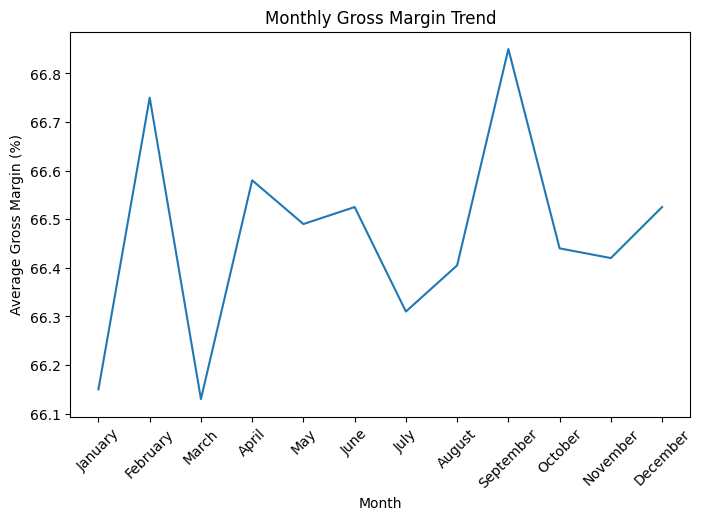

In [70]:
plt.figure(figsize=(8,5))

sns.lineplot(data=monthly_margin, x='Month', y='Gross_Margin_%', errorbar=None)

plt.title('Monthly Gross Margin Trend')
plt.xlabel('Month')
plt.ylabel('Average Gross Margin (%)')
plt.xticks(rotation=45)

plt.show()

- Gross margin remained highly stable throughout the year, fluctuating within a very narrow range of 66.1%–66.9%.
- The highest average margin was recorded in September (~66.85%), indicating the most profitable month.
- The lowest margin occurred in March (~66.13%), though the decline was minimal.
- Margin volatility is extremely low (0.32% standard deviation), showing consistent pricing and cost control.
- Despite large fluctuations in monthly revenue, profitability margins remained stable across all months.
- The business demonstrates strong operational efficiency, maintaining healthy margins regardless of sales volume changes.

## **Conclusion**

- The analysis reveals that Nassau Candy's revenue and profit are highly concentrated among a small group of products, indicating strong dependence on a limited number of top-performing items.

- Several Wonka Bar product variants consistently generate the highest sales, gross profit, and margins, making them the primary drivers of overall business performance.

- Product profitability analysis reveals that while several products generate strong sales, profitability varies across the portfolio, highlighting the importance of balancing revenue growth with margin performance.

- Division-level analysis identifies significant differences in revenue contribution and profitability across business segments, helping management prioritize resources toward higher-performing divisions.

- Pareto analysis confirms that a relatively small percentage of products contribute the majority of total revenue and gross profit, demonstrating a classic 80/20 concentration pattern.

- Revenue and profit concentration create dependency risks, as business performance is heavily influenced by a limited set of products.

- Cost structure diagnostics identify Kazookles as the most significant profitability concern, with exceptionally high costs and the lowest gross margin in the product portfolio.

- Kazookles exhibits pricing inefficiencies and poor margin performance, indicating a need for pricing review, cost reduction initiatives, or supplier renegotiation.

- Several high-cost products contribute significantly to revenue and profit but present opportunities for cost optimization through supplier negotiations.

- A small group of products generates relatively low sales and low profit contribution, making them suitable candidates for discontinuation review or portfolio rationalization.

- Monthly revenue analysis shows noticeable fluctuations throughout the year, with revenue increasing substantially during the final months, suggesting seasonal demand effects.

- Monthly gross margins remain highly stable throughout the year, with margin volatility of only 0.32%, indicating consistent pricing and profitability management.

- Nassau Candy should focus on strengthening its highest-performing products, reducing dependence on a few key items, optimizing supplier costs, improving underperforming product profitability, and leveraging seasonal demand patterns to maximize long-term revenue growth and profit performance.
